# **Predictive Analytics - Customer Churn Prediction**

## **Uploading the Dataset**

In [ ]:
import pandas as pd
# Load data
main_df = pd.read_csv('/content/main.csv')
train_labels = pd.read_csv('/content/train_cxid.csv')
test_ids = pd.read_csv('/content/test_cxid.csv')

# Merge with main to get full training dataset with features + churn labels
train_df_merged = pd.merge(train_labels, main_df, on='customer_id', how='inner')

# Merge test IDs with main to get test features (without labels)
test_df_merged = pd.merge(test_ids, main_df, on='customer_id', how='inner')

print("Train shape:", train_df_merged.shape)
print("Test shape:", test_df_merged.shape)
train_df_merged.head()

Train shape: (624048, 93)
Test shape: (156012, 93)


,customer_id,churn,usage_type,Day_1,Day_2,Day_3,Day_4,Day_5,Day_6,Day_7,...,Day_81,Day_82,Day_83,Day_84,Day_85,Day_86,Day_87,Day_88,Day_89,Day_90
0,a8cfed4379972f41e730a31a5c500e9ed2592374761b09...,0,usage_app_other,193.95,197.30,217.93,17.03,50.40,31.71,33.02,...,233.25,257.26,282.60,193.52,87.56,218.17,289.87,194.85,251.82,199.29
1,a8cfed4379972f41e730a31a5c500e9ed2592374761b09...,0,usage_app_youtube_daily,121.58,96.35,113.39,94.49,100.44,76.75,91.28,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2,a8cfed4379972f41e730a31a5c500e9ed2592374761b09...,0,usage_app_facebook_daily,0.00,205.76,203.19,107.87,236.90,0.00,100.87,...,438.66,363.89,177.43,528.85,722.56,533.39,127.41,58.02,348.49,621.46
3,a8cfed4379972f41e730a31a5c500e9ed2592374761b09...,0,usage_app_tiktok_daily,107.18,83.31,18.99,56.96,38.33,79.95,0.00,...,0.00,0.00,9.24,0.00,103.25,117.94,103.67,88.26,117.75,137.58
4,a8cfed4379972f41e730a31a5c500e9ed2592374761b09...,0,usage_app_whatsapp_daily,11.04,17.21,24.81,12.61,8.94,4.83,10.67,...,31.80,34.13,30.71,29.18,24.86,17.82,51.64,50.11,43.24,48.21


## **Data Pivoting**

In [ ]:
# Pivot so each row is a customer, columns = usage_type_day
train_pivot = train_df_merged.pivot_table(
    index='customer_id',
    columns='usage_type',
    values=[f'Day_{i}' for i in range(1, 91)]
)

# Flatten MultiIndex columns
train_pivot.columns = [f"{usage}_{day}" for day, usage in train_pivot.columns]
train_pivot.reset_index(inplace=True)

# Add churn label
train_final = pd.merge(train_pivot, train_labels, on='customer_id', how='left')

# Repeat for test
test_pivot = test_df_merged.pivot_table(
    index='customer_id',
    columns='usage_type',
    values=[f'Day_{i}' for i in range(1, 91)]
)
test_pivot.columns = [f"{usage}_{day}" for day, usage in test_pivot.columns]
test_pivot.reset_index(inplace=True)

## **Visualizing how features correlate with churn**

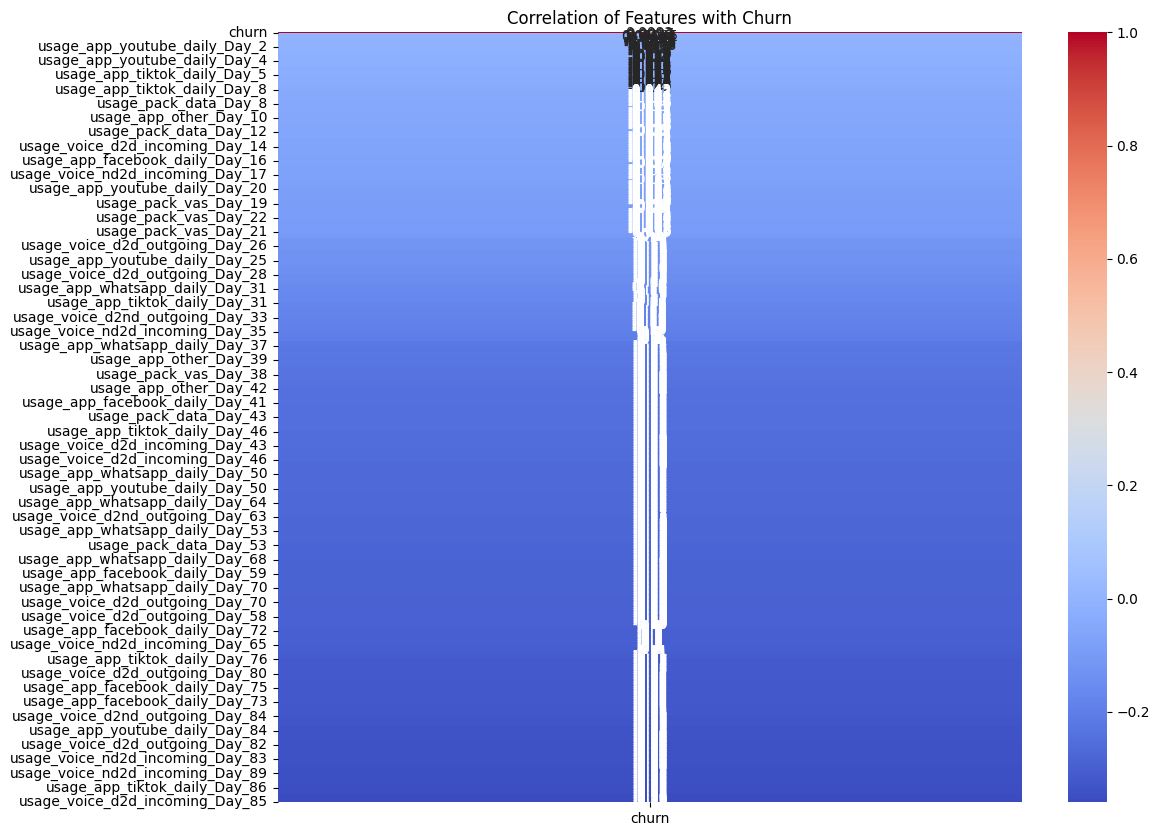

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Join churn labels for correlation
corr_df = train_final.drop(columns=['customer_id'])  # Drop customer_id for correlation
corr = corr_df.corr()

# Plot heatmap (optional: zoom into only top correlated features with churn)
plt.figure(figsize=(12, 10))
sns.heatmap(corr[['churn']].sort_values(by='churn', ascending=False), annot=True, cmap='coolwarm')
plt.title("Correlation of Features with Churn")
plt.show()

### Drops customer_id as it does not contribute to the Churn prediction

### Using **SHAP with XGBoost** to get interpretable feature importance

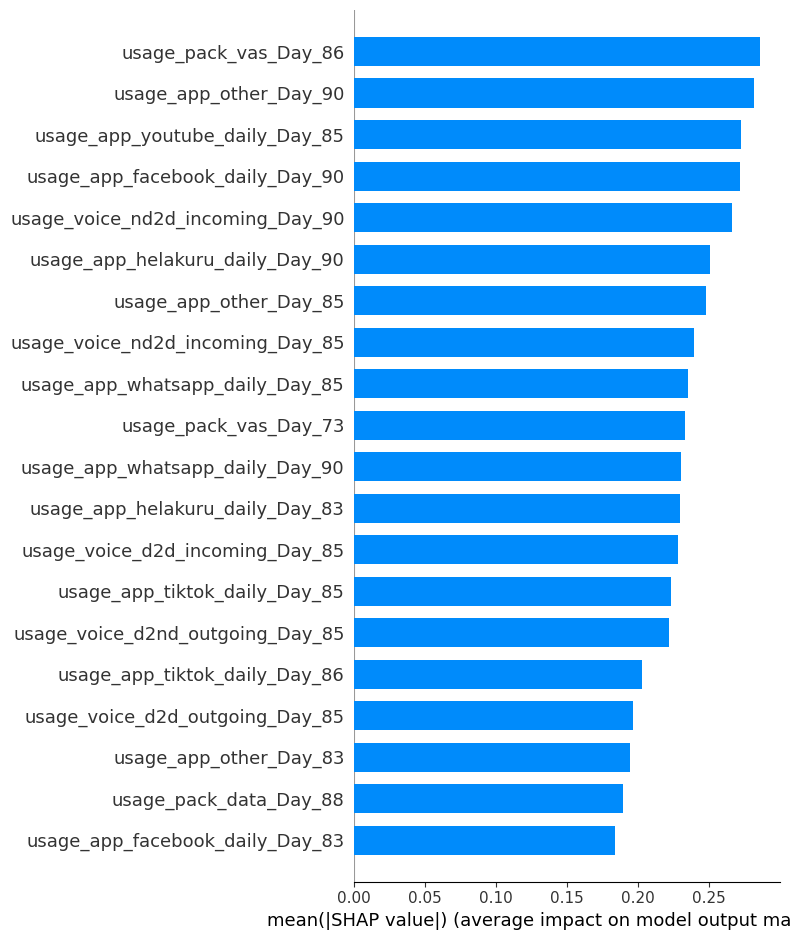

In [ ]:
import shap
import xgboost as xgb
from sklearn.model_selection import train_test_split

# Separate features and target
X = train_final.drop(columns=['customer_id', 'churn'])
y = train_final['churn']

# Train-test split (for SHAP calc)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit XGBoost model
model = xgb.XGBClassifier(n_estimators=100, max_depth=5, random_state=42)
model.fit(X_train, y_train)

# SHAP explainer
explainer = shap.Explainer(model)
shap_values = explainer(X_train)

# Plot feature importance
shap.summary_plot(shap_values, X_train, plot_type="bar")

## **Extracting the top features**

In [ ]:
import numpy as np
# Get mean absolute SHAP values per feature
shap_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': np.abs(shap_values.values).mean(axis=0)
})

# Sort by importance and select top N
top_n = 20
top_features = shap_importance.sort_values(by='importance', ascending=False).head(top_n)['feature'].tolist()

print("Top features selected:", top_features)

Top features selected: ['usage_pack_vas_Day_86', 'usage_app_other_Day_90', 'usage_app_youtube_daily_Day_85', 'usage_app_facebook_daily_Day_90', 'usage_voice_nd2d_incoming_Day_90', 'usage_app_helakuru_daily_Day_90', 'usage_app_other_Day_85', 'usage_voice_nd2d_incoming_Day_85', 'usage_app_whatsapp_daily_Day_85', 'usage_pack_vas_Day_73', 'usage_app_whatsapp_daily_Day_90', 'usage_app_helakuru_daily_Day_83', 'usage_voice_d2d_incoming_Day_85', 'usage_app_tiktok_daily_Day_85', 'usage_voice_d2nd_outgoing_Day_85', 'usage_app_tiktok_daily_Day_86', 'usage_voice_d2d_outgoing_Day_85', 'usage_app_other_Day_83', 'usage_pack_data_Day_88', 'usage_app_facebook_daily_Day_83']


In [ ]:
train_final['churn'].value_counts(normalize=True)

,proportion
churn,
0,0.768825
1,0.231175


## **Random undersampling to handle class imbalance**

In [ ]:
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import train_test_split

# Split features and target
X = train_final.drop(['customer_id', 'churn'], axis=1)
y = train_final['churn']

# Optional: split into train-test for model validation later
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply Undersampling
undersample = RandomUnderSampler(random_state=42)
X_train_resampled, y_train_resampled = undersample.fit_resample(X_train, y_train)

print("Original class distribution:\n", y.value_counts())
print("Resampled class distribution:\n", pd.Series(y_train_resampled).value_counts())


Original class distribution:
 churn
0    39982
1    12022
Name: count, dtype: int64
Resampled class distribution:
 churn
0    9625
1    9625
Name: count, dtype: int64


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [ ]:
X_train_resampled, y_train_resampled  # From SMOTE
X_val, y_val                          # From the 80/20 train/val split

(       usage_app_facebook_daily_Day_1  usage_app_helakuru_daily_Day_1  \
 13604                           78.52                           19.51   
 5373                           113.04                            8.77   
 27758                          156.75                           24.96   
 47722                            0.00                           12.73   
 40347                           81.52                            7.12   
 ...                               ...                             ...   
 6350                           122.72                            0.00   
 44230                           70.83                           11.08   
 2507                            73.83                           40.67   
 16454                           73.84                           19.97   
 43184                           72.00                           10.57   
 
        usage_app_other_Day_1  usage_app_tiktok_daily_Day_1  \
 13604                 237.56                  

## **Stacking ensemble model**

# 1. Base Learner
# 2. Meta Learner
# 3. Stacking classifier

In [ ]:
xgb = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    n_estimators=30,             # Reduced for faster training
    random_state=42
)

gb = GradientBoostingClassifier(
    n_estimators=30,             # Reduced for faster training
    random_state=42
)

In [ ]:
meta = LogisticRegression()

In [ ]:
stacking_model = StackingClassifier(
    estimators=[('xgb', xgb), ('gb', gb)],
    final_estimator=meta,
    cv=5,
    n_jobs=-1,
    passthrough=True
)

In [ ]:
stacking_model.fit(X_train_resampled, y_train_resampled)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


StackingClassifier(cv=5,
                   estimators=[('xgb',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsample_bytree=None,
                                              device=None,
                                              early_stopping_rounds=None,
                                              enable_categorical=False,
                                              eval_metric='logloss',
                                              feature_types=None, gamma=None,
                                              grow_policy=None,
                                              importance_type=None,
                                              interaction_constraints=None...
                                              max_cat_to_onehot=None,
                                              max_delta_step=None,
                                              max_depth=None, max_leaves=None,
                                              min_child_weight=None,
                                              missing=nan,
                                              monotone_constraints=None,
                                              multi_strategy=None,
                                              n_estimators=30, n_jobs=None,
                                              num_parallel_tree=None,
                                              random_state=42, ...)),
                               ('gb',
                                GradientBoostingClassifier(n_estimators=30,
                                                           random_state=42))],
                   final_estimator=LogisticRegression(), n_jobs=-1,
                   passthrough=True)

## **Standard evaluation**

In [ ]:
y_pred = stacking_model.predict(X_val)

print("Classification Report:\n", classification_report(y_val, y_pred))
print("Accuracy:", accuracy_score(y_val, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.98      0.98      8004
           1       0.92      0.98      0.95      2397

    accuracy                           0.98     10401
   macro avg       0.96      0.98      0.97     10401
weighted avg       0.98      0.98      0.98     10401

Accuracy: 0.9766368618402077
Confusion Matrix:
 [[7809  195]
 [  48 2349]]


## **High recall** (0.98) for churn class → Your model is catching almost all churners (great for retention strategy).

## **Precision** (0.92) for churn → Most of the predicted churners actually churn.

## **F1-Score** (0.95) for churn class → Balanced performance between precision & recall.

## **With Accuracy being 97.6%**

## **Test set prediction pipeline**

In [ ]:
test_final = test_df_merged.copy()  # rename to match your prediction step

In [ ]:
# Manually encode object columns in test_final (and training data if needed)
for col in test_final.select_dtypes(include='object').columns:
    if col != 'customer_id':  # Skip ID column
        test_final[col] = test_final[col].astype('category').cat.codes

In [ ]:
# Assuming 'test_pivot' has the features for the test set:
test_final = test_pivot # Rename test_pivot to test_final
# Now, proceed with the prediction:
test_probs = stacking_model.predict_proba(test_final.drop(columns=['customer_id']))[:, 1]

In [ ]:
# Step 1: Save training feature list
trained_features = X_train_resampled.columns.tolist()  # Change X_sample to X_train_resampled

# Step 2: Clean test set
test_clean = test_final.drop(columns=['customer_id'], errors='ignore')
if 'churn' in test_clean.columns:
    test_clean = test_clean.drop(columns=['churn'])

# Step 3: Align columns
test_clean = test_clean.reindex(columns=trained_features, fill_value=0)

# Step 4: Predict
test_probs = stacking_model.predict_proba(test_clean)[:, 1]

## **Cross Validation**

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_auc_score
import pandas as pd
import time

USE_FAST_MODE = True  # Flip to False when you're ready for full training

if USE_FAST_MODE:
    X_sample = X_train_resampled.sample(1000, random_state=42)
    y_sample = y_train_resampled.loc[X_sample.index]
else:
    X_sample = X_train_resampled
    y_sample = y_train_resampled

# Encode categorical columns to numeric
non_numeric_cols = X_sample.select_dtypes(include=['object']).columns
for col in non_numeric_cols:
    X_sample[col] = X_sample[col].astype('category').cat.codes
    test_final[col] = test_final[col].astype('category').cat.codes

# Cross-validation
print("Running cross-validation...")
start_time = time.time()

cv_scores = cross_val_score(
    stacking_model,
    X_sample,
    y_sample,
    cv=3 if USE_FAST_MODE else 5,
    scoring='roc_auc',
    n_jobs=-1
)

print(f" Mean CV AUC Score: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"CV done in {time.time() - start_time:.2f} seconds")

# Train on full/sample
print("Training model...")
stacking_model.fit(X_sample, y_sample)

# Save trained feature list
trained_features = X_sample.columns.tolist()

# Clean and align test set
test_clean = test_final.drop(columns=['customer_id'], errors='ignore')
if 'churn' in test_clean.columns:
    test_clean = test_clean.drop(columns=['churn'])

test_clean = test_clean.reindex(columns=trained_features, fill_value=0)

# Predict churn
print("Generating churn probabilities...")
test_probs = stacking_model.predict_proba(test_clean)[:, 1]

# Create submission
submission = pd.DataFrame({
    'customer_id': test_final['customer_id'],
    'churn_probability': test_probs
})

print("Preview of predictions:")
print(submission.head())

Running cross-validation...
 Mean CV AUC Score: 0.9886 ± 0.0055
CV done in 109.10 seconds
Training model...
Generating churn probabilities...
Preview of predictions:
                                         customer_id  churn_probability
0  e4b72c1c45b982f8b39f4cab732c433b24d03d52e5a0b1...           0.500197
1  e4b72c1c45b982f8b39f4cab732c433b24d03d52e5a0b1...           0.500197
2  e4b72c1c45b982f8b39f4cab732c433b24d03d52e5a0b1...           0.500197
3  e4b72c1c45b982f8b39f4cab732c433b24d03d52e5a0b1...           0.500197
4  e4b72c1c45b982f8b39f4cab732c433b24d03d52e5a0b1...           0.500197


# **ROC Curve**

Evaluation Metrics on Resampled Training Data:
Accuracy:  0.9589
Precision: 0.9455
Recall:    0.9738
F1 Score:  0.9595
AUC Score: 0.9915


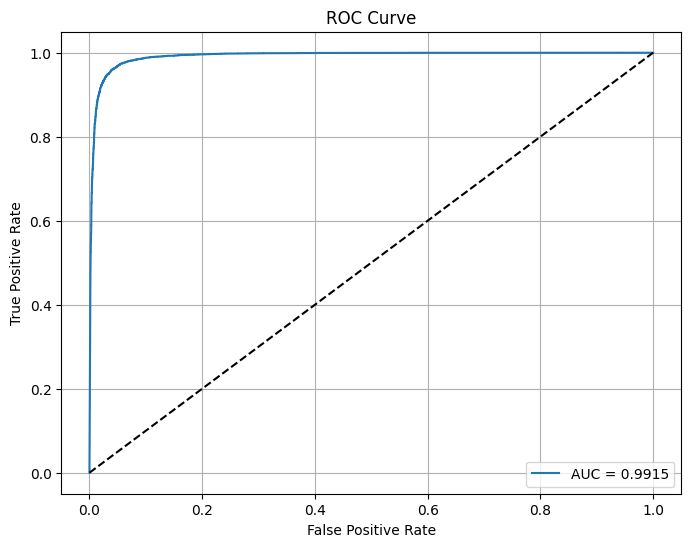

,customer_id,churn,usage_type,Day_1,Day_2,Day_3,Day_4,Day_5,Day_6,Day_7,...,Day_83,Day_84,Day_85,Day_86,Day_87,Day_88,Day_89,Day_90,churn_probability,predicted_churn_risk
0,e4b72c1c45b982f8b39f4cab732c433b24d03d52e5a0b1...,1,2,156.93,99.10,89.69,38.20,130.39,140.53,55.86,...,0.0,0.00,0.00,0.0,0.00,0.0,0.0,0.00,0.500197,1
1,e4b72c1c45b982f8b39f4cab732c433b24d03d52e5a0b1...,1,5,118.39,112.94,109.39,103.32,99.02,92.64,87.47,...,0.0,0.00,0.00,0.0,0.00,0.0,0.0,0.00,0.500197,1
2,e4b72c1c45b982f8b39f4cab732c433b24d03d52e5a0b1...,1,0,56.87,106.22,72.35,123.96,165.69,47.45,0.00,...,0.0,0.00,0.00,0.0,0.00,0.0,0.0,0.00,0.500197,1
3,e4b72c1c45b982f8b39f4cab732c433b24d03d52e5a0b1...,1,3,66.97,61.30,57.31,51.93,54.37,48.98,47.79,...,0.0,0.00,0.00,0.0,0.00,0.0,0.0,0.00,0.500197,1
4,e4b72c1c45b982f8b39f4cab732c433b24d03d52e5a0b1...,1,4,9.36,16.38,24.79,1.07,8.61,21.89,0.00,...,0.0,11.16,12.55,0.0,0.41,0.0,0.0,9.48,0.500197,1


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# First, predict on validation set (optional - or use training set performance)
y_pred = stacking_model.predict(X_train_resampled)
y_proba = stacking_model.predict_proba(X_train_resampled)[:, 1]

# 1. Evaluation Metrics
print("Evaluation Metrics on Resampled Training Data:")
print(f"Accuracy:  {accuracy_score(y_train_resampled, y_pred):.4f}")
print(f"Precision: {precision_score(y_train_resampled, y_pred):.4f}")
print(f"Recall:    {recall_score(y_train_resampled, y_pred):.4f}")
print(f"F1 Score:  {f1_score(y_train_resampled, y_pred):.4f}")
print(f"AUC Score: {roc_auc_score(y_train_resampled, y_proba):.4f}")

# 2. Plot ROC Curve
fpr, tpr, _ = roc_curve(y_train_resampled, y_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_train_resampled, y_proba):.4f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

# 3. Add churn risk prediction to main test dataset
test_final['churn_probability'] = test_probs
test_final['predicted_churn_risk'] = (test_probs > 0.5).astype(int)  # Threshold can be changed

test_final.head()

## AUC = 0.9915 Indicatng that the model has outstanding discriminative ability between the positive and negative classes.

# **High-Value Customer Identification**

In [ ]:

# 1. Define 'Total Usage' feature
test_final['Total_Usage'] = test_final[[col for col in test_final.columns if col.startswith('usage')]].sum(axis=1)

# 2. Create 'HVC Score' (combine churn probability and usage)
# You might need to adjust weights (0.7, 0.3) based on your business context
test_final['HVC_Score'] = 0.7 * (1 - test_final['churn_probability']) + 0.3 * (test_final['Total_Usage'] / test_final['Total_Usage'].max())

# 3. Identify HVCs based on a threshold (e.g., top 20%)
threshold = test_final['HVC_Score'].quantile(0.8)  # Adjust quantile as needed
test_final['High_Value_Customer'] = (test_final['HVC_Score'] >= threshold).astype(int)

# 4. Explore and analyze HVCs
print("Number of High-Value Customers:", test_final['High_Value_Customer'].sum())
print("HVC Characteristics:")
print(test_final[test_final['High_Value_Customer'] == 1].describe())

Number of High-Value Customers: 39003
HVC Characteristics:
              churn    usage_type         Day_1         Day_2         Day_3  \
count  39003.000000  39003.000000  39003.000000  39003.000000  39003.000000   
mean       0.229059     10.000000     24.360103     24.114002     24.102822   
std        0.420233      0.816507     25.136211     25.393329     25.543267   
min        0.000000      9.000000      0.000000      0.000000      0.000000   
25%        0.000000      9.000000     15.380000     14.595000     14.270000   
50%        0.000000     10.000000     19.990000     20.100000     20.170000   
75%        0.000000     11.000000     24.670000     24.580000     24.550000   
max        1.000000     11.000000    315.600000    343.910000    337.830000   

              Day_4         Day_5         Day_6         Day_7         Day_8  \
count  39003.000000  39003.000000  39003.000000  39003.000000  39003.000000   
mean      23.417600     23.813073     22.353812     22.327628     21.92

# **Combine Risk & Value**

1. Filter customers with high churn risk (churn_risk_prob >= threshold) and high value.
2. Output list of high-risk, high-value customers.


In [ ]:
churn_threshold = 0.5

high_risk_value_customers = test_final[
    (test_final['churn_probability'] >= churn_threshold) &
    (test_final['High_Value_Customer'] == 1)
]

print("High-Risk High-Value Customers:", len(high_risk_value_customers))
print(high_risk_value_customers[['churn_probability', 'High_Value_Customer', 'Total_Usage', 'HVC_Score', 'customer_id']].head())


High-Risk High-Value Customers: 39003
    churn_probability  High_Value_Customer  Total_Usage  HVC_Score  \
6            0.500197                    1            9   0.595317   
7            0.500197                    1           10   0.622589   
9            0.500197                    1           11   0.649862   
18           0.500197                    1            9   0.595317   
19           0.500197                    1           10   0.622589   

                                          customer_id  
6   e4b72c1c45b982f8b39f4cab732c433b24d03d52e5a0b1...  
7   e4b72c1c45b982f8b39f4cab732c433b24d03d52e5a0b1...  
9   e4b72c1c45b982f8b39f4cab732c433b24d03d52e5a0b1...  
18  b9996abf8720c9c554b78617f27827c18e597b378227d2...  
19  b9996abf8720c9c554b78617f27827c18e597b378227d2...  


# **Generate Retention Recommendations**


In [ ]:
import pandas as pd

def generate_recommendations(customer_data):
    recommendations = []

    # Normalize Total_Usage
    customer_data['Normalized_Usage'] = (customer_data['Total_Usage'] - customer_data['Total_Usage'].min()) / (customer_data['Total_Usage'].max() - customer_data['Total_Usage'].min())

    for index, row in customer_data.iterrows():
        customer_id = row['customer_id']
        churn_prob = row['churn_probability']
        normalized_usage = row['Normalized_Usage']

        # Basic recommendations based on churn probability and normalized usage
        recs = []
        if churn_prob > 0.85 and normalized_usage < 0.25:  # High churn risk, low usage
            recs.extend(["Offer personalized discounts", "Proactively contact customer", "Prioritize service improvements"])
        elif churn_prob > 0.6 and normalized_usage < 0.5:  # Moderate churn risk, moderate usage
            recs.extend(["Offer loyalty program benefits", "Targeted marketing campaign", "Monitor usage patterns"])
        elif churn_prob > 0.6 and normalized_usage >= 0.5: # Moderate churn risk, high usage
            recs.extend(["Offer premium services", "Gather feedback", "Reward loyalty"])
        elif churn_prob <= 0.6 and normalized_usage < 0.25: # Low churn risk, low usage
            recs.extend(["Encourage usage with promotions", "Introduce new features", "Personalize onboarding"])
        elif churn_prob <= 0.6 and normalized_usage >= 0.5: # Low churn risk, high usage
            recs.extend(["Maintain current engagement", "Offer exclusive content/features", "Gather feedback for improvements"])
        else:  # Lower churn risk (still HVC), moderate usage
            recs.extend(["Offer loyalty program benefits", "Targeted marketing campaign", "Monitor usage patterns"])


        recommendations.append({
            'customer_id': customer_id,
            'recommendations': recs
        })

    return pd.DataFrame(recommendations)

# Assuming 'test_final' contains churn_probability and Total_Usage:
recommendations_all_df = generate_recommendations(test_final)
print(recommendations_all_df)
recommendations_all_df.to_csv('customer_recommendations_all.csv', index=False)
print("Recommendations for all customers have been saved to 'customer_recommendations_all.csv'.")

                                              customer_id  \
0       e4b72c1c45b982f8b39f4cab732c433b24d03d52e5a0b1...   
1       e4b72c1c45b982f8b39f4cab732c433b24d03d52e5a0b1...   
2       e4b72c1c45b982f8b39f4cab732c433b24d03d52e5a0b1...   
3       e4b72c1c45b982f8b39f4cab732c433b24d03d52e5a0b1...   
4       e4b72c1c45b982f8b39f4cab732c433b24d03d52e5a0b1...   
...                                                   ...   
156007  92d06de871b7d60b0dbf7cae5f1eb2cd719e7a3fa87d8f...   
156008  92d06de871b7d60b0dbf7cae5f1eb2cd719e7a3fa87d8f...   
156009  92d06de871b7d60b0dbf7cae5f1eb2cd719e7a3fa87d8f...   
156010  92d06de871b7d60b0dbf7cae5f1eb2cd719e7a3fa87d8f...   
156011  92d06de871b7d60b0dbf7cae5f1eb2cd719e7a3fa87d8f...   

                                          recommendations  
0       [Encourage usage with promotions, Introduce ne...  
1       [Offer loyalty program benefits, Targeted mark...  
2       [Encourage usage with promotions, Introduce ne...  
3       [Offer loyalty prog